# Predicting Distributed Systems Failure

## Using machine learning models to predict the state of distributed systems
### Frank Wang
### PSTAT 231

## Table of Contents
1. [Introduction](#introduction)
2. [Motive](#motive)
3. [Project Outline](#project-outline)
4. [Exploratory Data Analsyis](#exploratory-data-analysis)
    * [Describing Our Predictors](#describing-our-predictors)
    * [Loading and Splitting the Data](#loading-and-splitting-the-data)
5. [Model Training](#model-training)
    * [Setting up the Pipeline](#setting-up-the-pipeline)
    * [Training the Models](#training-the-models)
    * [Model Results](#model-results)
    * [Plotting Feature Importance](#plotting-feature-importance)
    * [Evaluating Performance](#evaluating-performance)
6. [Conclusion](#conclusion)
7. [Extension: Classifying Root Cause](#extension-classifying-root-cause)
8. [Extension: Removing Late-Stage Indicators](#extension-removing-late-stage-indicators)


## Introduction
The goal of this project is to build a machine learning model to predict the the state of a distributed system. I obtained the dataset on Kaggle, and it is artificial data simulated based on realistic system conditions. This will be a multi-class classification problem. Throughout this project, I will implement multiple machine learning models to get the best results. 

## Motive
Distributed architecture has become the norm for tech companies nowadays. As services scale, it becomes cheaper, more reliable, and faster to divide tasks previously performed on one machine to many machines. This can be seen in the rise of cloud services like AWS. However, this creates a lot more complexity, as it is much harder to manage the status of many machines compared to just one. In addition, a problem in one machine can cascade to all the other machines. Early detection of system failures can save a company millions of dollars, and it is a problem many companies have already tackled.

## Project Outline
To build the model, I will first perform a train-test split on the dataset. I will then perform EDA on the training set to better understand the distribution of the data and gain some insights. Next, I will build a sklearn pipeline that will perform the preprocessing steps before training the models. Using this pipeline, I will train a variety of machine learning models and use 5 fold cross validation to find the best model. Using this best model, I will evaluate it's performance on the testing set and conclude my findings.

## Exploratory Data Analysis
Before we can start training models, we need to visualize the data and run some preliminarly analysis to gain some insights. Because the data is artificially generated, there are no missing values, so we do not have to use any form of imputation.

### Describing Our Predictors
The dataset consists of many common statistics modern day systems have, like network latency and packet loss percentage. We also have two target variables that we want to classify each system into, which is the system's current state and the root cause of the problem if it exists.

Let's first look at all of our predictors: 
- architecture_type: The high-level distributed architecture pattern (monolith, microservices, event-driven, serverless, hybrid)
- deployment_type: How the application is hosted (on-prem, cloud, hybrid)
- communication_type: How services communicate with each other (eg. mixed, sync, async)
- num_services: The number of individual services running
- num_databases: The number of databases used
- requests_per_second: The number of requests per second
- avg_payload_kb: The average size of the data packets being transferred in Kilobytes
- read_write_ratio: The ratio between data reads and writes
- peak_traffic_multiplier: A factor representing how much traffic is occurring relative to average load
- cpu_utilization_percent: The percent usage of CPU
- memory_utilization_percent: The percent usage of memory(RAM)
- network_latency_ms: The current network latency (time for packets to reach destination)
- packet_loss_percent: The percentage of data packets that fail to reach their destination
- avg_latency_ms: The average time for the system to process a request
- p95_latency_ms: The 95th percentile of the system's latency
- error_rate_percent: The percentage of total requests that result in errors
- db_connection_pool_exhausted: A binary flag indicating if the database has run out of available connections for new requests
- retry_storm_detected: A flag indicating if failed requests are retrying so rapidly they are overwhelming the system
- circuit_breaker_open: A flag indicating if a circuit breaker has triggered, stopping all requests from reaching the service

We will be using these 2 variables as our target variables:
- system_state: The current state of the system (eg: healthy, degraded)
- root_cause: The root cause (if applicable) behind the system failure. It will be none if system is healthy (eg: network_partition, database_lock)

These are a lot of predictors, but for modern systems, these are common metrics that most systems should have. As such, this is representative of the information many modern systems would use to try to detect system failures. With this in mind, we can start exploring the data.

### Loading and Splitting the Data
Before we start, let's set up our environment by downloading the necessary packages and load the csv file downloaded from Kaggle.

In [1]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score, roc_auc_score, RocCurveDisplay

In [2]:
df = pd.read_csv("distributed_system_architecture_stress_dataset.csv")

With the dataset loaded, we can separate it into our predictor variables and our target variables. In this case, our target variables will be system_state and root_cause. For the bulk of our project, we will focus on system state. I will separate the target variables into two separate data structures to make this clear.

In [3]:
X = df.drop(["system_state", "root_cause"], axis=1)
y = df[["system_state", "root_cause"]]

X_train, X_test, y_train_df, y_test_df = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y["system_state"],
    random_state=42
)

y_train_system = y_train_df["system_state"]
y_test_system  = y_test_df["system_state"]

y_train_cause = y_train_df["root_cause"]
y_test_cause = y_test_df["root_cause"]

### Visualization of Data
With the data loaded, we can go ahead and perform EDA. I will only perform EDA on the training dataset to prevent data leakage. Let's first look at the shape of the predictors.

A majority of the predictors are heavily right skewed, as shown below.

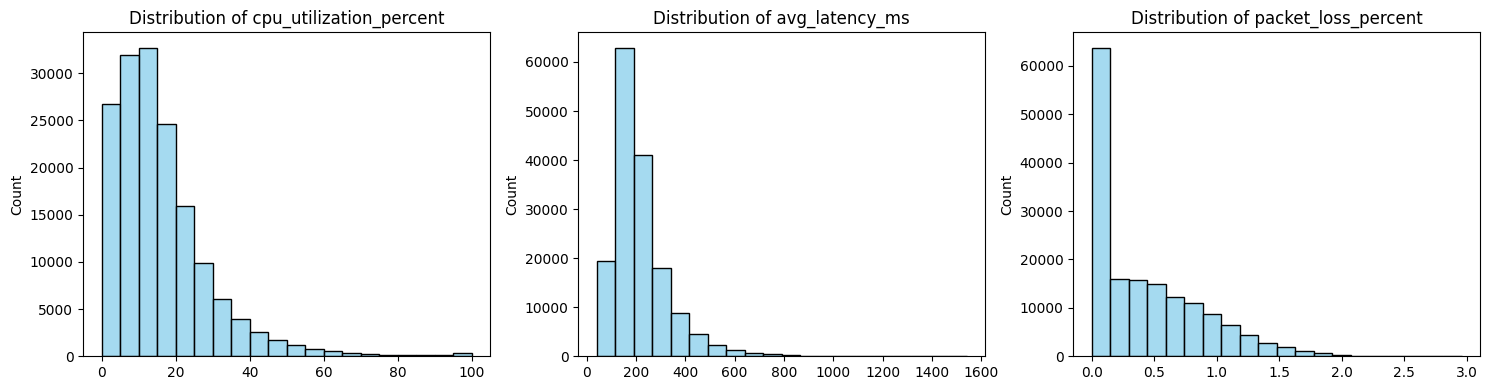

In [4]:
cols = ["cpu_utilization_percent", "avg_latency_ms", "packet_loss_percent"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))  # 1 row, 3 columns

for ax, col in zip(axes, cols):
    sns.histplot(X_train[col], bins=20, kde=False, ax=ax, color="skyblue")
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel("")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

This includes requests per second, cpu utilization, network latency, average and 95th percentile latency, and error rate. This makes sense because for the majority of the time, these systems should not be operating under maximal load. It is typically when traffic spikes and these systems are forced to use all of their resources that failures occur.

Next, let's check the distribution of our target variables: system state and root cause.

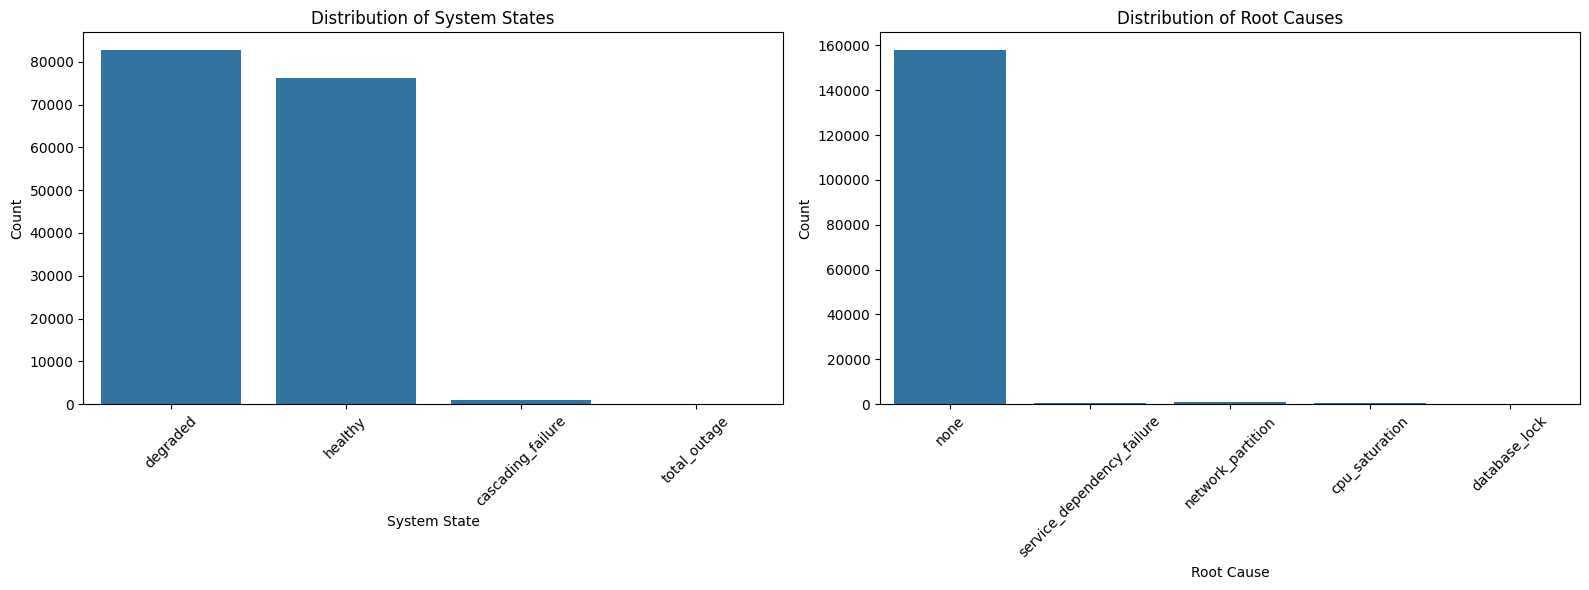

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# system state plot
sns.countplot(data=y_train_df, x="system_state", ax=axes[0])
axes[0].set_title("Distribution of System States")
axes[0].set_xlabel("System State")
axes[0].set_ylabel("Count")

# root cause plot
sns.countplot(data=y_train_df, x="root_cause", ax=axes[1])
axes[1].set_title("Distribution of Root Causes")
axes[1].set_xlabel("Root Cause")
axes[1].set_ylabel("Count")

# rotate x labels to not overlap
for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Looking at the distributions, we see that the majority of system states are either degraded or healthy, with minimal cascading failures and total outages. Similarly, root cause is mainly none. Because I stratified on system state earlier, I can be confident that the our training and test set has similar distributions of system states. However, I didn't stratify on root cause, so we will have to check that later.

I will plot the percentage of each root cause category side by side for the training and testing distributions. I will also use a log scale on the y-axis to better visualize the graph.

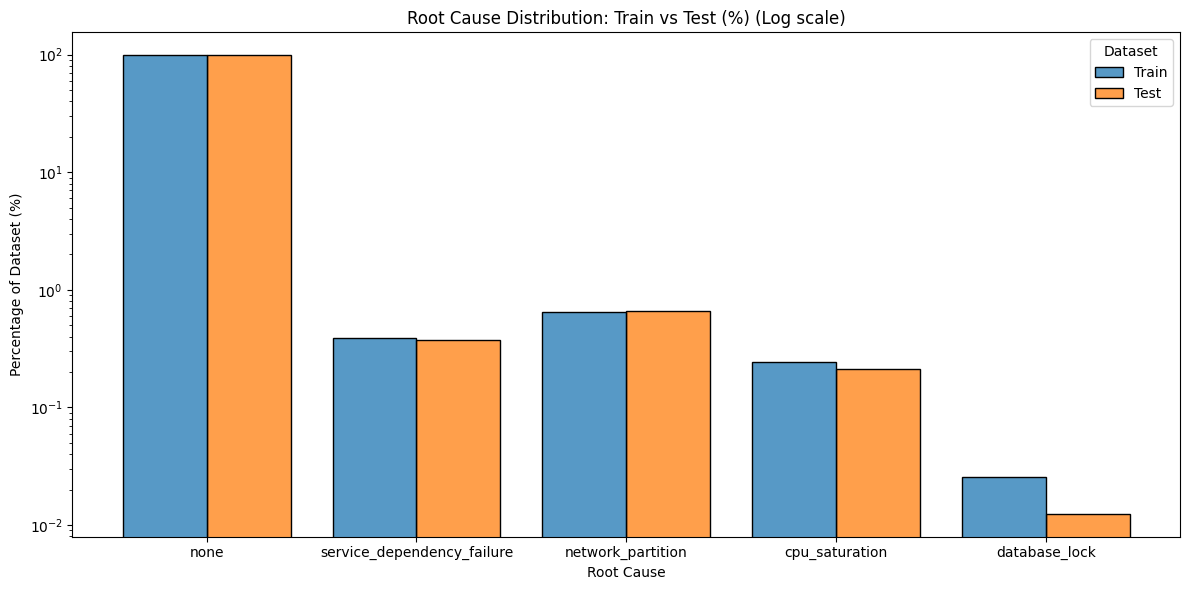

In [6]:
# label datasets
train_plot = y_train_df[['root_cause']].copy()
train_plot['Dataset'] = 'Train'

test_plot = y_test_df[['root_cause']].copy()
test_plot['Dataset'] = 'Test'

# combine datasets
combined_df = pd.concat([train_plot, test_plot])

plt.figure(figsize=(12, 6))
ax = sns.histplot(
    data=combined_df, 
    x="root_cause", 
    hue="Dataset", 
    multiple="dodge", 
    shrink=0.8,           
    stat="percent",     # normalize to percentages
    common_norm=False   # calculates percentage indepedendently
)

ax.set_yscale("log")
plt.title("Root Cause Distribution: Train vs Test (%) (Log scale)")
plt.ylabel("Percentage of Dataset (%)")
plt.xlabel("Root Cause")
plt.tight_layout()
plt.show()

We see that the training and test sets have similar distributions of root cause as well, so we can be more confident that our model will be able to better fit the test set for root cause.

## Model Training
Now that we have made sure that there are no unexpected anomalies within the data, we can start training different models. I've already split the data, so we do not need to do that step again.
### Setting up the Pipeline
Next, I set up a preprocessing pipeline to process the data before training a model on it. This pipeline scales all the numerical variables and one hot encodes the categorical variables. Since the data is artificial, we do not need to do other steps like imputing missing values, which makes our job much easier. I will set sparse_output to false because the kNN model does not do as well with sparse datasets.

In [7]:
# define the categories to apply each transformation
categorical_cols = ["architecture_type", "deployment_type", "communication_type"]
numerical_cols = X_train.columns.drop(categorical_cols)

# create preprocesser
preprocess = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols) # sparse for knn model
])

### Training the Models
With our pipeline set up, we can get the cross validation scores of all our different models to find the best performing model on the training set. I will train a logistic regression, linear discriminant analysis, decision tree, extra trees, random forest, and k-NN model. 

First, I will do the logistic regression model separately, and we can check the cross validation scores. I set the class weight parameter to balanced because the dataset is extremely imbalanced, and I want to penalize it more for missing rare cases. I will also use F1 weighted as the metric for cross validation to evaluate the performance for the same reason. For models with tunable hyperparameters, I will be using a grid search to find the best set of parameters. Then, I will store the best F1 mean scores for the best version of model along with the trained model. This will allow me to directly take the best model and test it with our testing data.

In [8]:
# initialize
results_list = []
trained_models = {}

# create pipeline with preprocessing and model
lr_pipeline = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

# get cv scores and fit model
cv_scores = cross_val_score(lr_pipeline, X_train, y_train_system, cv=5, scoring='f1_weighted')
lr_pipeline.fit(X_train, y_train_system)

# store results
trained_models["Logistic Regression"] = lr_pipeline
results_list.append({
    "Model": "Logistic Regression",
    "Best_F1_Mean": cv_scores.mean(),
    "Best_F1_Std": cv_scores.std(),
    "Best_Params": {}
})

results_df = pd.DataFrame(results_list)

We are able to see the mean and standard deviation of the F1 score fore the logistic regression model. Now, we can do the same steps and do cross validation for the remaining models. We display the results in a Pandas dataframe in order to find the model with the best F1 score so that we can test it with the testing set.

In [9]:
# all models and hyper parameters
models = {
    "LDA": (LinearDiscriminantAnalysis(), {}),
    "Decision Tree": (DecisionTreeClassifier(class_weight="balanced", random_state=42), {
        "model__max_depth": [None, 10, 20]
    }),
    "Extra Trees": (ExtraTreesClassifier(class_weight="balanced", random_state=42), {
        "model__n_estimators": [100, 200]
    }),
    "Random Forest": (RandomForestClassifier(class_weight="balanced", random_state=42), {
        "model__n_estimators": [100, 200]
    }),
    "k-NN": (KNeighborsClassifier(), {
        "model__n_neighbors": [3, 7, 15]
    })
}

for name, (model_instance, param_grid) in models.items():
    # create pipeline
    pipeline = Pipeline([
        ("prep", preprocess),
        ("model", model_instance)
    ])
    
    # get cv scores and fit model
    grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1_weighted')
    grid.fit(X_train, y_train_system)

    # store best set of parameters model
    trained_models[name] = grid.best_estimator_
    
    best_index = grid.best_index_
    row = {
        "Model": name,
        "Best_F1_Mean": grid.cv_results_['mean_test_score'][best_index],
        "Best_F1_Std": grid.cv_results_['std_test_score'][best_index],
        "Best_Params": grid.best_params_
    }

    results_list.append(row)

results_df = pd.DataFrame(results_list).sort_values(by="Best_F1_Mean", ascending=False).reset_index(drop=True)
results_df

,Model,Best_F1_Mean,Best_F1_Std,Best_Params
0,Decision Tree,0.999937,0.000019,{'model__max_depth': None}
1,Random Forest,0.999904,0.000035,{'model__n_estimators': 200}
2,Logistic Regression,0.988575,0.000532,{}
3,Extra Trees,0.982954,0.000626,{'model__n_estimators': 200}
4,LDA,0.913122,0.001569,{}
5,k-NN,0.895970,0.002134,{'model__n_neighbors': 15}


### Model Results
Looking at our results, we see that the decision tree with no max depth actually had the best F1 mean. In a close second is random forest with 200 estimators, and in third is logistic regression. We also see that all the models actually did relatively well, with k-NN doing the worst. These results are suprisingly high. This typically means that there are some predictors that have a strong relationship with system_state. My initial fear was that some form of data leak occurred, but since this is cross fold validation on only the training set, that shouldn't be a problem. Another potential problem could be that X_train has some predictors that real systems shouldn't have; however, after inspecting the data, all the columns are as they should be. The most common problem is overfitting, and we can compare the F1 scores to see if that's the case.

### Plotting Feature Importance
Since the F1 scores are so high, this typically means that some predictors have an extremely strong relationship with system_state. Let's look at the feature importances for the best performing model, decision tree.

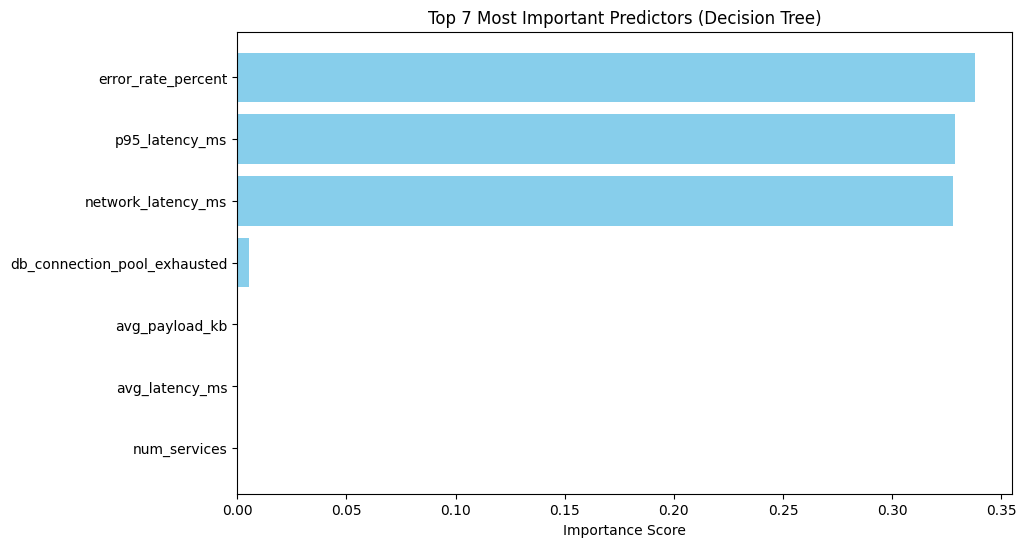

In [10]:
# look at best model
best_model = trained_models['Decision Tree'] 

# get the predictor variable names and their importance value
cat_encoder = best_model.named_steps['prep'].named_transformers_['cat']
cat_features = cat_encoder.get_feature_names_out(categorical_cols)
all_features = np.concatenate([numerical_cols, cat_features])
importances = best_model.named_steps['model'].feature_importances_

# create and sort df
feat_imp_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'].head(7), feat_imp_df['Importance'].head(7), color='skyblue')
plt.xlabel('Importance Score')
plt.title('Top 7 Most Important Predictors (Decision Tree)')
plt.gca().invert_yaxis()
plt.show()

As expected, we see that the top 3 predictors of error_rate_percent, p95_latency_ms, and network_latency_ms are by far the most important predictors. This explains why all the models did so well because there is a very simple rule governing the classification of the system state. Since the error rate could be a form of late stage detection, we will later try to remove these late stage detection variables and try to train our models again. However, for now, let's evaluate the performance of the best model: decision tree with 

### Evaluating Performance
Now that we've picked our best model, let's evaluate it's performance on the actual testing set. First, we can just do a visual check of the confusion matrix. To do that, we need to create predictions using the trained model and put them into a confusion matrix.

<Figure size 800x600 with 0 Axes>

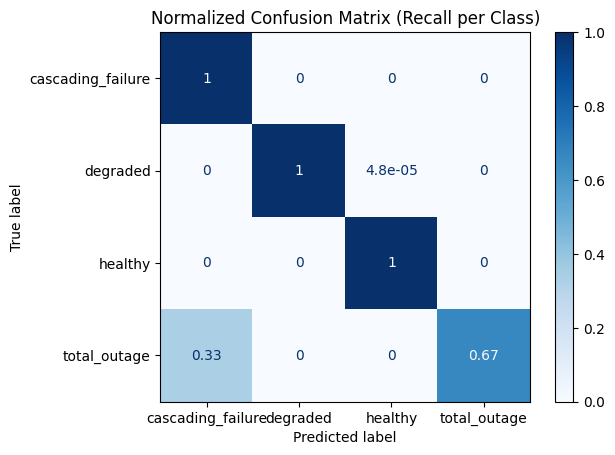

In [11]:
# create predictions and cm
y_pred = best_model.predict(X_test)
cm_normalized = confusion_matrix(y_test_system, y_pred, normalize='true')

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, 
                              display_labels=best_model.classes_)

disp.plot(cmap='Blues') 
plt.title("Normalized Confusion Matrix (Recall per Class)")
plt.show()

It looks like the performance is really good, with our only errors in the total_outage label, and it's only 1/3 of the time. It's not as bad either because the system is still labeled as cascading_failure, which would warn engineers to check the state of the system either way. More importantly, the two majority classes of healthy and degraded actually are correctly classified 100% of the time, which is amazing. This means that our models weren't overfitting, but rather the classification problem itself has straight forward rules that the models picked up on.

Let's also check the F1 score and ROC AUC score. The F1 score is good for imbalanced data sets like this one, and the ROC AUC score shows how good the model is at ranking systems that are degraded or failing. For the ROC AUC score, we can plot the ROC AUC curve for each class, showing how good the model is for each one.

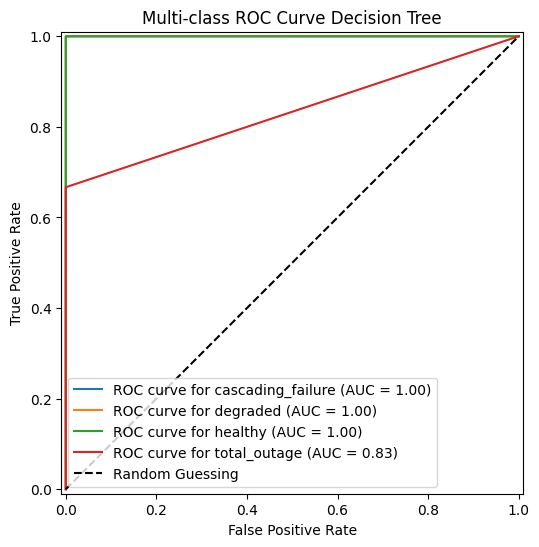

Final Evaluation for Decison Tree:
Weighted F1 Score: 0.9999
Weighted ROC AUC:  1.0000


In [12]:
y_probs = best_model.predict_proba(X_test)

fig, ax = plt.subplots(figsize=(8, 6))

for i, class_name in enumerate(best_model.classes_):
    RocCurveDisplay.from_predictions(
        y_test_system == class_name, 
        y_probs[:, i], 
        name=f"ROC curve for {class_name}",
        ax=ax
    )

plt.plot([0, 1], [0, 1], "k--", label="Random Guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Multi-class ROC Curve Decision Tree")
plt.legend()
plt.show()

f1 = f1_score(y_test_system, y_pred, average='weighted')
auc = roc_auc_score(y_test_system, y_probs, multi_class='ovr', average='weighted')

print(f"Final Evaluation for Decison Tree:")
print(f"Weighted F1 Score: {f1:.4f}")
print(f"Weighted ROC AUC:  {auc:.4f}")

As expected, the F1 score and ROC AUC score are both extremely high. This also lets us know that the models are not overfitting. Also, we see that the ROC AUC curve for total_outage is slightly lower compared to the other curves, which also makes sense because that was the only one that misclassified a few entries.

Another benefit of the decision tree model is that we can visually see the logical flow to classify the system state. However, during our preprocessing step, all the numerical values were scaled, so they don't make sense in the usual context. One thing we can do is undo the scaling performed in our preprocessing step so that we can see the actual values that form the cutoff thresholds.

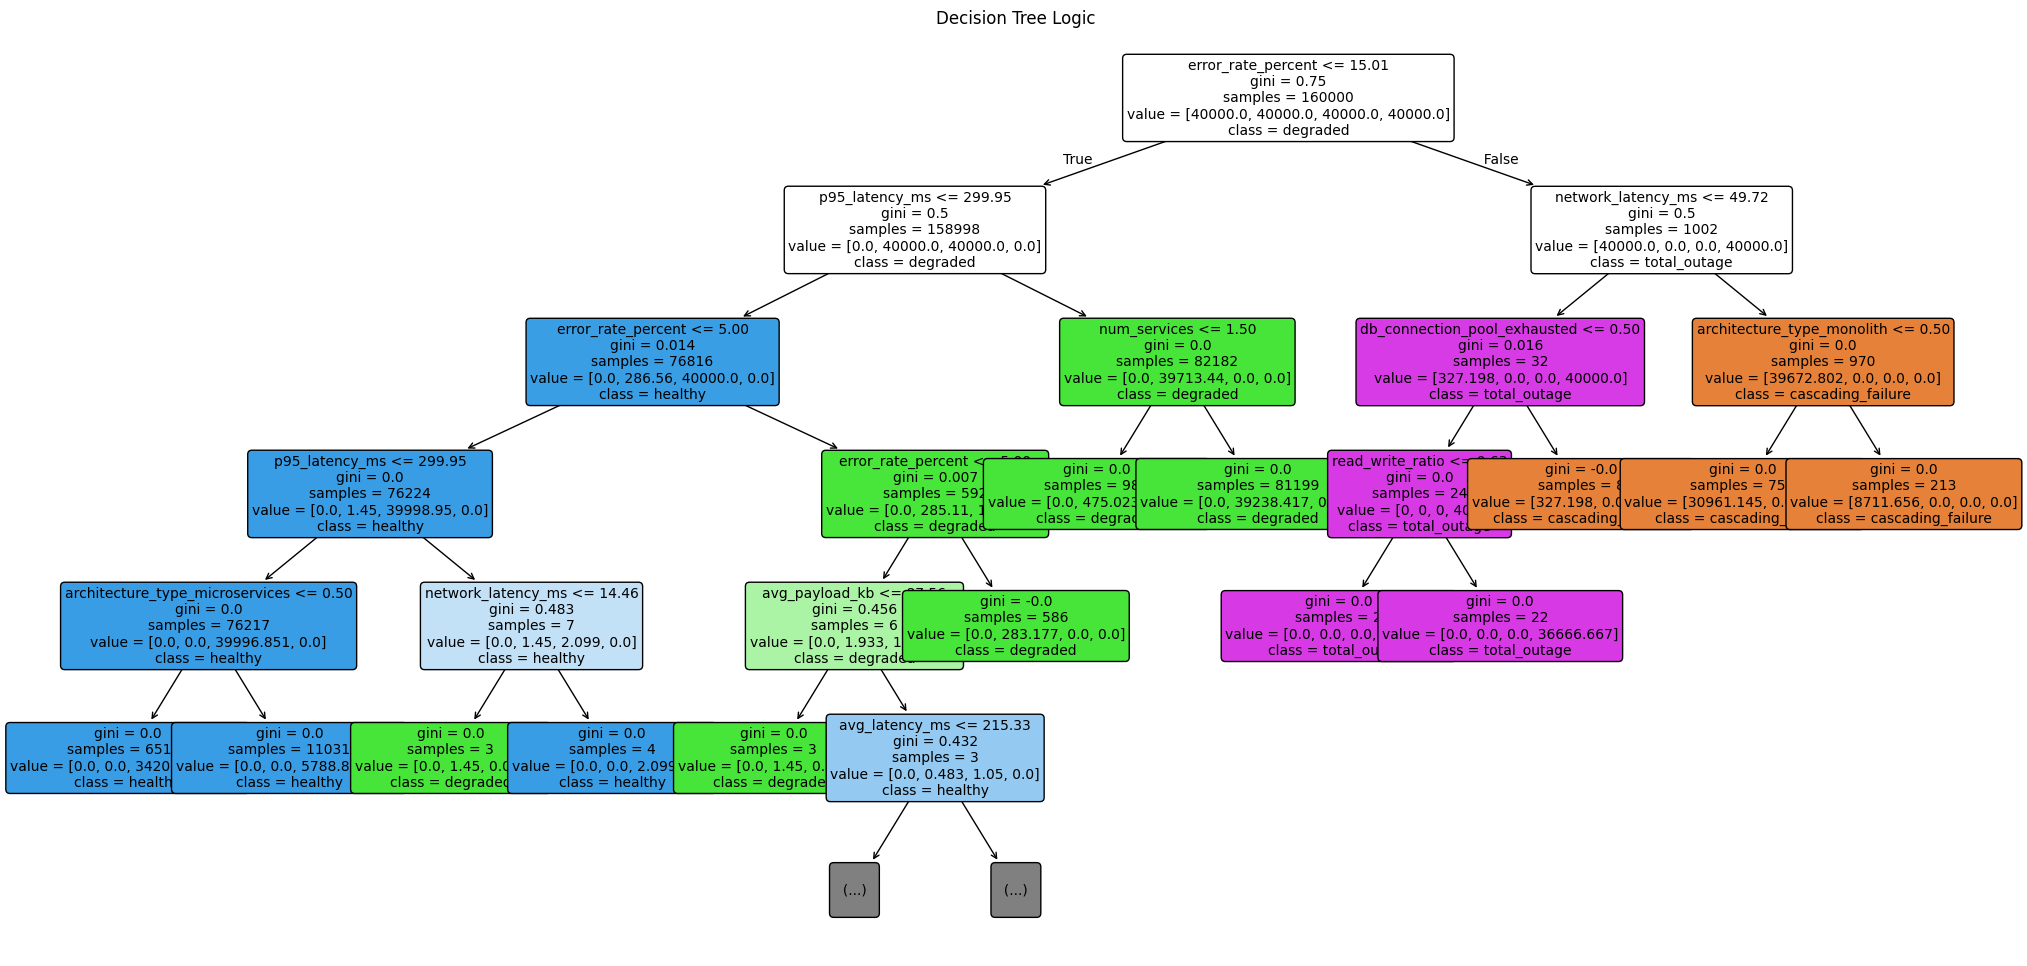

In [13]:
def plot_unscaled_decision_tree(pipeline, num_cols, cat_cols, title="Decision Tree Logic (Real-World Values)", max_depth=3):
    # get model and preprocessor
    dt_model = pipeline.named_steps['model']
    preprocessor = pipeline.named_steps['prep']

    # get scaler settings
    scaler = preprocessor.named_transformers_['num']
    stats_map = {
        feature: {"mean": m, "std": s} 
        for feature, m, s in zip(num_cols, scaler.mean_, scaler.scale_)
    }

    # function to reverse scaling
    def unscale_threshold(feature_name, threshold):
        if feature_name in stats_map:
            mu = stats_map[feature_name]["mean"]
            sigma = stats_map[feature_name]["std"]
            return (threshold * sigma) + mu
        return threshold

    # get feature names
    cat_encoder = preprocessor.named_transformers_['cat']
    cat_features = cat_encoder.get_feature_names_out(cat_cols)
    all_feature_names = np.concatenate([num_cols, cat_features])

    # plot tree
    plt.figure(figsize=(25, 12))
    annotations = plot_tree(
        dt_model,
        feature_names=all_feature_names,
        class_names=pipeline.classes_,
        filled=True,
        rounded=True,
        max_depth=max_depth,
        fontsize=10
    )

    # replace text with new values
    for text_obj in annotations:
        text = text_obj.get_text()
        lines = text.split('\n')
        
        # if box is a decision node
        if '<=' in lines[0]:
            feature_name, threshold_str = lines[0].split(' <= ')
            
            # reverse scaling
            z_score = float(threshold_str)
            real_value = unscale_threshold(feature_name, z_score)
            lines[0] = f"{feature_name} <= {real_value:.2f}"
            
            # update text
            text_obj.set_text('\n'.join(lines))

    plt.title(title)
    plt.show()

plot_unscaled_decision_tree(
    pipeline=best_model,
    num_cols=numerical_cols, 
    cat_cols=categorical_cols,
    title="Decision Tree Logic",
    max_depth=5
)

Looking at this decision tree, we can follow the decisions the tree makes at each step. Each box represents a node where a decision is made. Following the rules, the decision tree splits the data into more and more categories. As you can see, if the error_rate_percent is greater than 15.01, then it automatically classifies it as one of the failing states. In each node, gini represents the purity of the node, or the composition of the different elements. The samples tells you how many samples are in that node that need to be split. The value is the count of each class at that node. Finally, the class is just the majority label at that node. As you can see, a decision tree is an easily understandable model.

## Conclusion
As it turns out, for this data set, classifying system state is pretty easy due to certain predictors having an extremely high importance. The best performing model were the tree based models. This signifies that there are certain predictors that are of high importance. The fact that the decision tree was the best performing model shows that the data is very simple. This is shown in our tree, where it mainly makes decisions off of error_rate_percent and occasionally p95_latency_ms. 

It is expected that LDA didn't do as well because it assumes data normality. However, as show in the EDA, most of the data is right skewed. The fact that logistic regression did so well could be a testament to the simplicity of the data, showing that there is some linear correlation between the variables.

The worst model by far was k-NN. This could be due to the fact that I have 21 predictors, so it could be suffering from the "curse of dimensionality."

While the results were very good, I can't help but wonder if this was because of the artificial nature of the data. Also, I still want to try to identify the root cause of system failure, which would be a big help for engineers debugging system failures. I will address these questions next.

## Extension: Classifying Root Cause
It can often be useful to identify the root cause of a problem. This can be valuable information to improve the system architecture to prevent similar failures in the future. We can follow similar steps for predicting the system state and adapt it to root cause. 

Since we only care about root cause if the system state is not healthy, I will first remove all rows where system state is healthy first.

In [14]:
train_mask = y_train_df["system_state"] != "healthy"

X_train_filtered = X_train[train_mask]
y_train_filtered = y_train_cause[train_mask]

test_mask = y_test_df["system_state"] != "healthy"

X_test_filtered = X_test[test_mask]
y_test_filtered = y_test_cause[test_mask]

Since we are removing all healthy system states and healthy states are a large part of a dataset, I want to make sure that we aren't removing too much. In addition, I also want to make sure that the data between the testing and training set are roughly stratified. Since I only stratified on system_state, it's possible that the root_cause variable is uneven between the two data sets. I will also set the y-axis to a logarithmic scale since there is much more nones compared to the other classes.

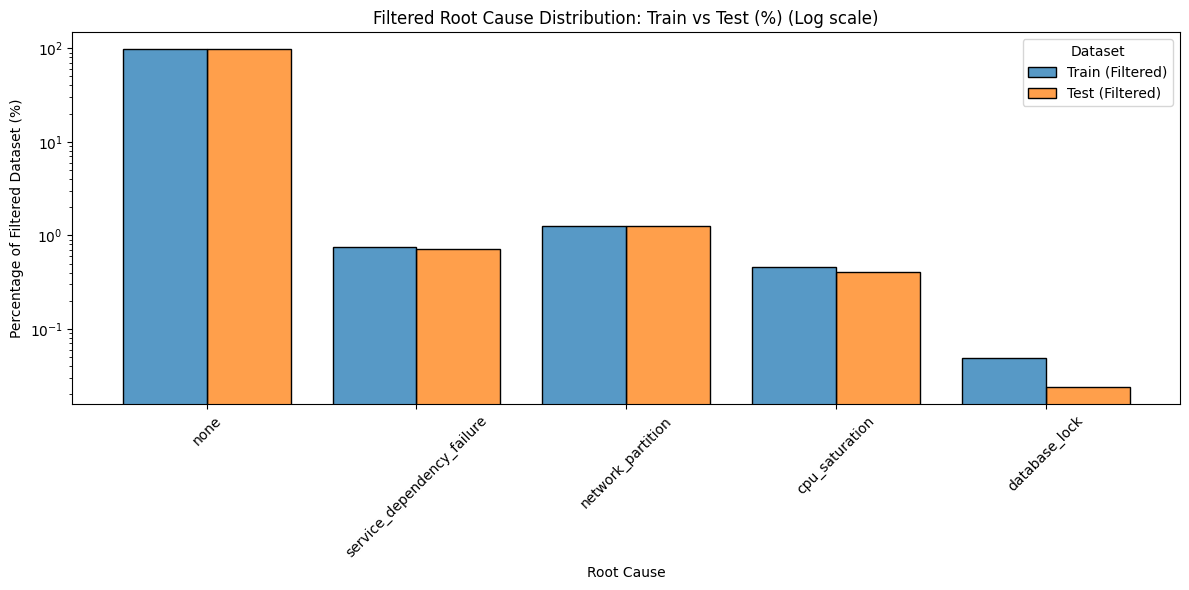

In [15]:
# convert into dataframes
train_plot = pd.DataFrame({"root_cause": y_train_filtered})
train_plot['Dataset'] = 'Train (Filtered)'

test_plot = pd.DataFrame({"root_cause": y_test_filtered})
test_plot['Dataset'] = 'Test (Filtered)'

# combine
combined_df = pd.concat([train_plot, test_plot])

plt.figure(figsize=(12, 6))
ax = sns.histplot(
    data=combined_df, 
    x="root_cause", 
    hue="Dataset", 
    multiple="dodge", 
    shrink=0.8,           
    stat="percent",     # normalize to percentages
    common_norm=False   # calculates percentage independently for train vs test
)

ax.set_yscale("log")
plt.title("Filtered Root Cause Distribution: Train vs Test (%) (Log scale)")
plt.ylabel("Percentage of Filtered Dataset (%)")
plt.xlabel("Root Cause")

# Added this to make sure the root cause names don't overlap
plt.xticks(rotation=45) 

plt.tight_layout()
plt.show()

As you can see, even though we didn't stratify on root_cause, the testing and training sets still have similar distributions. This will help the models better adapt to the testing set.

Lastly, let's check to make sure that we didn't remove too much of our dataset.

In [16]:
removed_train = len(X_train) - len(X_train_filtered)
removed_test = len(X_test) - len(X_test_filtered)

print(f"Training Set: Removed {removed_train} (Healthy), Remaining: {len(X_train_filtered)}")
print(f"Test Set: Removed {removed_test} (Healthy), Remaining: {len(X_test_filtered)}")

Training Set: Removed 76223 (Healthy), Remaining: 83777
Test Set: Removed 19056 (Healthy), Remaining: 20944


As we can see, it removed roughly half of the data set from both the training and the testing set, so the split is still roughly 80-20. Also, 80000 rows is still a relatively large dataset, so we can try to train a model.

With those rows filtered, we can repeat the same steps of generating a preprocessing pipeline, training a model, and verifying with cross validation.

In [17]:
results_list_cause = []
trained_models_cause = {}

models = {
    "Logistic Regression": (LogisticRegression(max_iter=1000, class_weight="balanced"), {}),
    "LDA": (LinearDiscriminantAnalysis(), {}),
    "Decision Tree": (DecisionTreeClassifier(class_weight="balanced", random_state=42), {
        "model__max_depth": [None, 10, 20]
    }),
    "Extra Trees": (ExtraTreesClassifier(class_weight="balanced", random_state=42), {
        "model__n_estimators": [100, 200]
    }),
    "Random Forest": (RandomForestClassifier(class_weight="balanced", random_state=42), {
        "model__n_estimators": [100, 200]
    }),
    "k-NN": (KNeighborsClassifier(), {
        "model__n_neighbors": [3, 7, 15]
    })
}

for name, (model_instance, param_grid) in models.items():
    pipeline = Pipeline([
        ("prep", preprocess),
        ("model", model_instance)
    ])
    
    grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1_weighted')
    grid.fit(X_train_filtered, y_train_filtered)

    trained_models_cause[name] = grid.best_estimator_
    
    best_index = grid.best_index_
    row = {
        "Model": name,
        "Best_F1_Mean": grid.cv_results_['mean_test_score'][best_index],
        "Best_F1_Std": grid.cv_results_['std_test_score'][best_index],
        "Best_Params": grid.best_params_
    }

    results_list_cause.append(row)

results_df_cause = pd.DataFrame(results_list_cause).sort_values(by="Best_F1_Mean", ascending=False).reset_index(drop=True)
results_df_cause

,Model,Best_F1_Mean,Best_F1_Std,Best_Params
0,Decision Tree,0.999964,0.000029,{'model__max_depth': None}
1,Random Forest,0.999964,0.000029,{'model__n_estimators': 200}
2,Extra Trees,0.997865,0.000363,{'model__n_estimators': 100}
3,Logistic Regression,0.997105,0.000500,{}
4,k-NN,0.992905,0.000526,{'model__n_neighbors': 3}
5,LDA,0.981382,0.000806,{}


Interestingly, the best model again is decision tree with max depth of none, but random forest has the exact same score and standard deviation. Interestingly, k-NN didn't perform as bad this time, and all the models had a F1 score of above 0.98. 

Since the results are unusually good, let's visually inspect the predictor importance again.

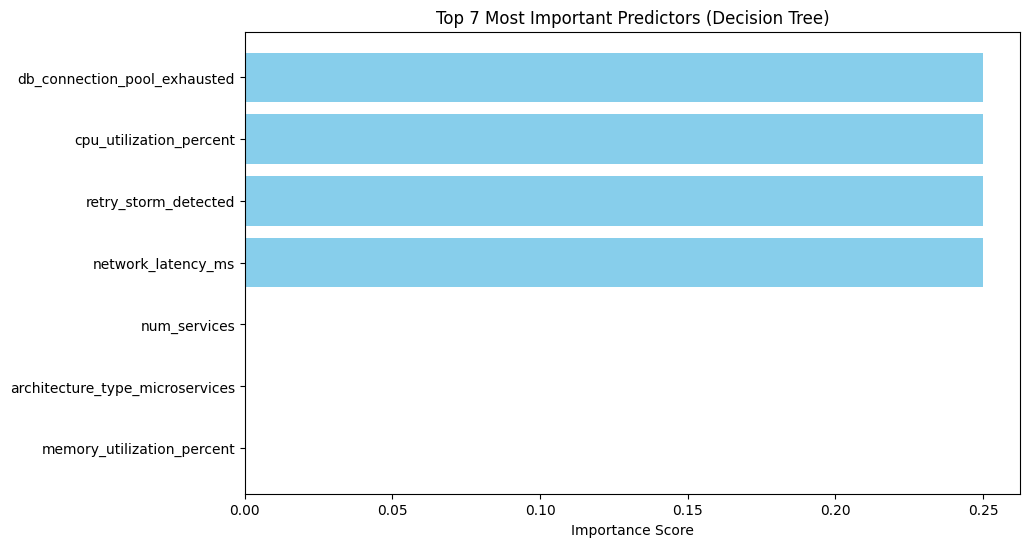

In [18]:
# look at best model
best_model = trained_models_cause['Decision Tree'] 

# get the predictor variable names and their importance value
cat_encoder = best_model.named_steps['prep'].named_transformers_['cat']
cat_features = cat_encoder.get_feature_names_out(categorical_cols)
all_features = np.concatenate([numerical_cols, cat_features])
importances = best_model.named_steps['model'].feature_importances_

# create and sort df
feat_imp_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'].head(7), feat_imp_df['Importance'].head(7), color='skyblue')
plt.xlabel('Importance Score')
plt.title('Top 7 Most Important Predictors (Decision Tree)')
plt.gca().invert_yaxis()
plt.show()

As we can see, it seems, this time, the decision tree only needs these 4 variables to accurately classify root cause. Let's check what actual decisions it's making based off of these variables in the decision tree plot.

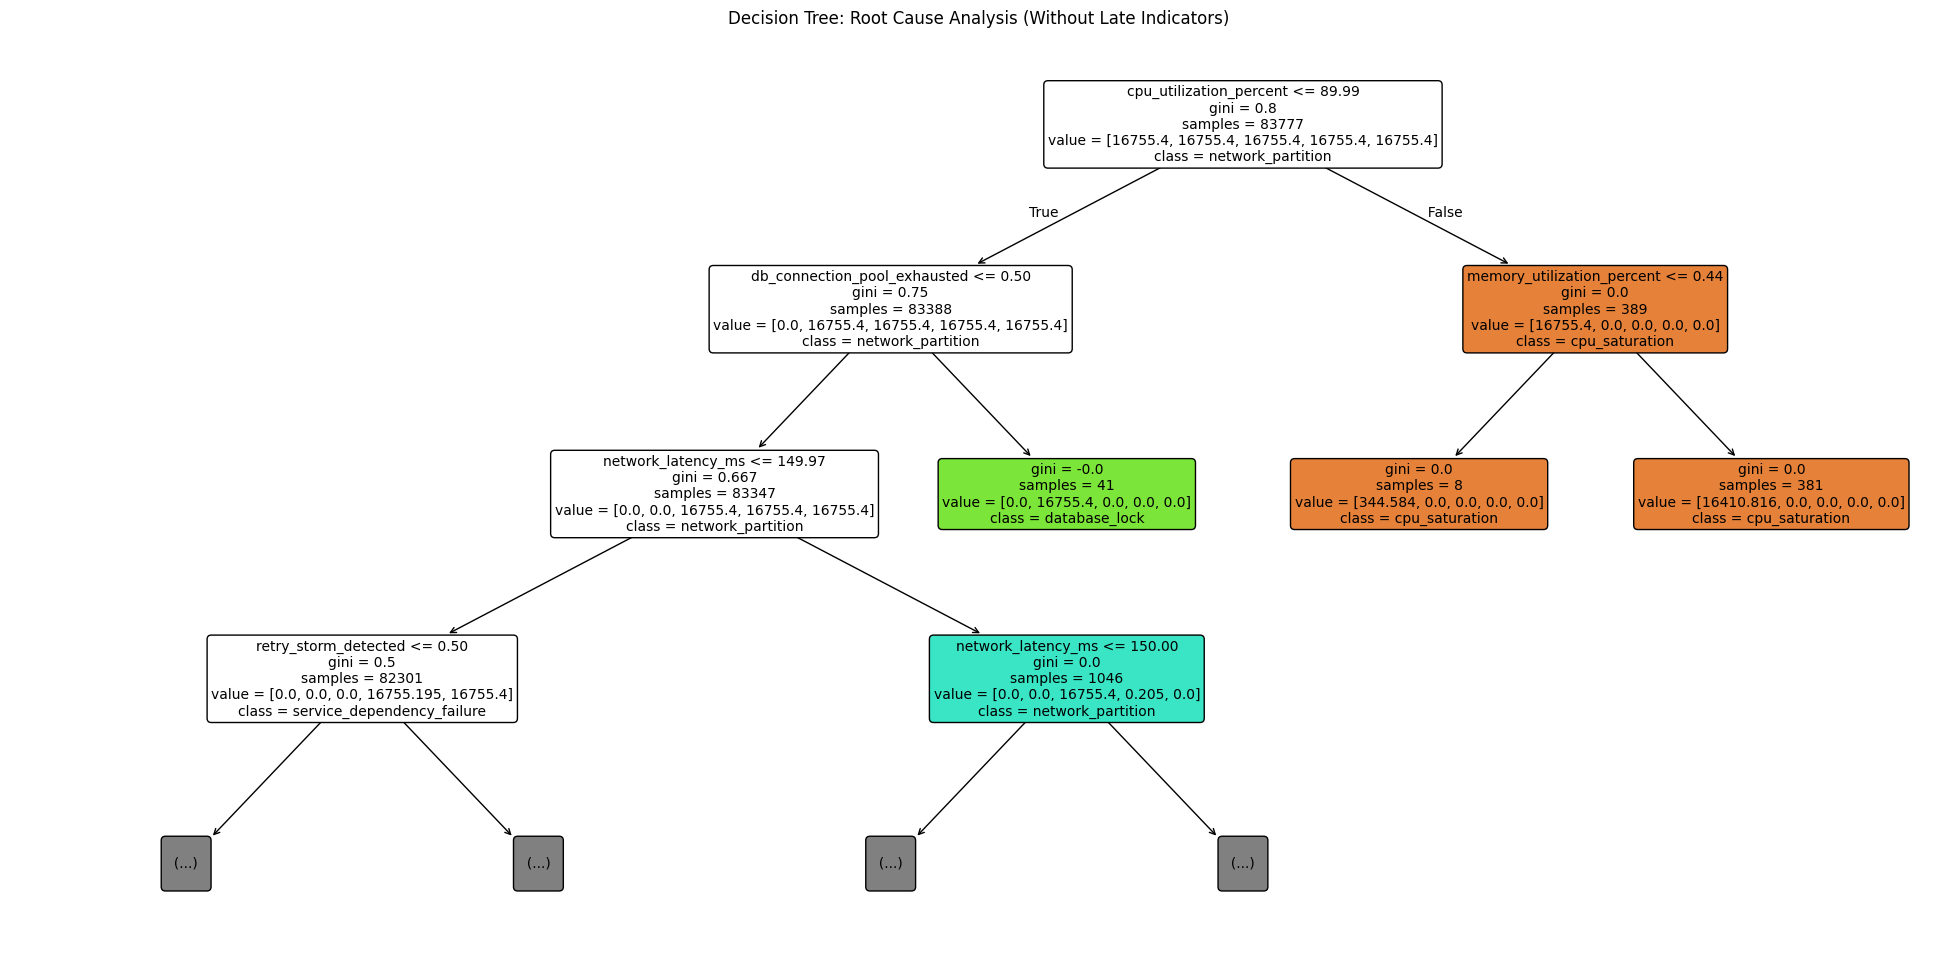

In [19]:
plot_unscaled_decision_tree(
    pipeline=trained_models_cause["Decision Tree"],
    num_cols=numerical_cols, 
    cat_cols=categorical_cols,
    title="Decision Tree: Root Cause Analysis (Without Late Indicators)",
    max_depth=3
)

As a reminder, db_pool_exhausted and retry_storm_detected are binary flags, so when it says less than 0.50, it just means either 0 or 1. Looking at these decisions, they make a lot of sense. For example if cpu utilization is high, the problem is probably cpu saturation. Similarly, if the database connection pool is exhausted, it's probably a database lock.

With this in mind, let's check the decision tree's performance on the actual testing set.

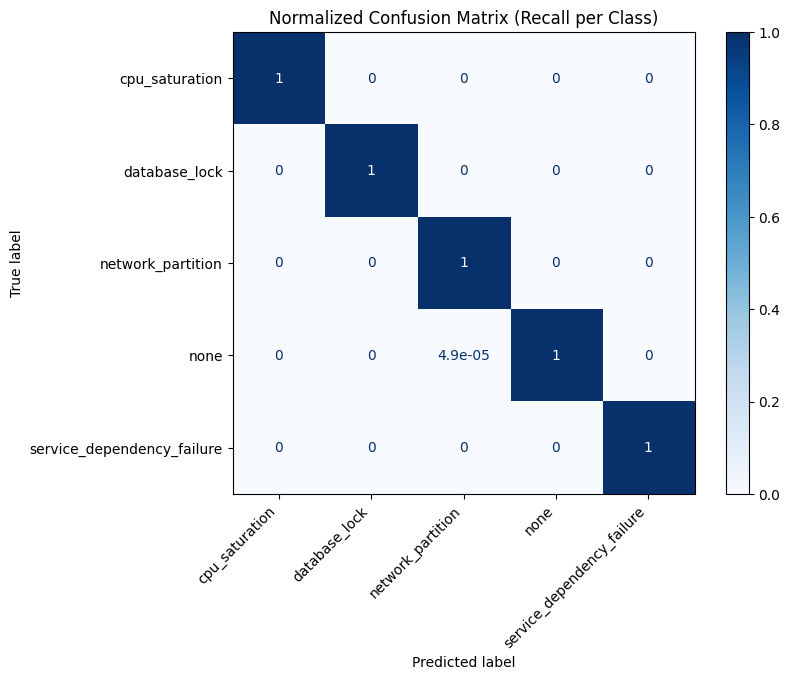

In [20]:
y_pred = best_model.predict(X_test_filtered)

cm_normalized = confusion_matrix(y_test_filtered, y_pred, normalize='true')

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, 
                              display_labels=best_model.classes_)

disp.plot(cmap='Blues', ax=plt.gca()) 
plt.xticks(rotation=45, ha='right')
plt.title("Normalized Confusion Matrix (Recall per Class)")
plt.show()

We see that there is almost no misclassifications, with the only one's being the none class being classified as a network partition. Again, this isn't the biggest problem because this is just giving engineers a hint about what direction to look in.

We can also check the F1 and ROC AUC score.

In [21]:
y_probs = best_model.predict_proba(X_test_filtered)

f1 = f1_score(y_test_filtered, y_pred, average='weighted')
auc = roc_auc_score(y_test_filtered, y_probs, multi_class='ovr', average='weighted')

print(f"Final Evaluation for Decison Tree:")
print(f"Weighted F1 Score: {f1:.4f}")
print(f"Weighted ROC AUC:  {auc:.4f}")

Final Evaluation for Decison Tree:
Weighted F1 Score: 1.0000
Weighted ROC AUC:  1.0000


As expected, the scores are approximately 1 since we only had very few misclassifications. We see that, similar to system state, root cause is very easy for these models to classify. The scores are even better across all classes for root cause compared to system state.

## Extension: Removing Late-stage Indicators
As we noticed earlier, some predictors were by far the most important for classifying system state, namely error_rate_percent, p95_latency_ms, and network_latency_ms. Sometimes though, these warning signs are too late. Ideally, we would want to catch that the system state is degraded before the error rate and latency increases drastically. 

As such, an interesting exercise is trying to remove these predictors and see how our models perform. First, we need to remove the columns from our X set.

In [22]:
late_stage_cols = ['error_rate_percent', 'p95_latency_ms', 'network_latency_ms']

# remove columns
X_train_late_stage = X_train.drop(columns=late_stage_cols, errors='ignore')
X_test_late_stage = X_test.drop(columns=late_stage_cols, errors='ignore')

# modify preprocessor 
numerical_cols_late_stage = [col for col in numerical_cols if col not in late_stage_cols]

prep_late_stage = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols_late_stage),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)


With the predictors removed, we can once again use cross validation on our different models to find the model with the best performance.

In [23]:
results_list_late_stage= []
trained_models_late_stage = {}
models = {
    "Logistic Regression": (LogisticRegression(max_iter=1000, class_weight="balanced"), {}),
    "LDA": (LinearDiscriminantAnalysis(), {}),
    "Decision Tree": (DecisionTreeClassifier(class_weight="balanced", random_state=42), {
        "model__max_depth": [None, 10, 20]
    }),
    "Extra Trees": (ExtraTreesClassifier(class_weight="balanced", random_state=42), {
        "model__n_estimators": [100, 200]
    }),
    "Random Forest": (RandomForestClassifier(class_weight="balanced", random_state=42), {
        "model__n_estimators": [100, 200]
    }),
    "k-NN": (KNeighborsClassifier(), {
        "model__n_neighbors": [3, 7, 15]
    })
}

for name, (model_instance, param_grid) in models.items():
    pipeline = Pipeline([
        ("prep", prep_late_stage),
        ("model", model_instance)
    ])
    
    grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1_weighted')
    grid.fit(X_train_late_stage, y_train_system)

    trained_models_late_stage[name] = grid.best_estimator_
    
    best_index = grid.best_index_
    row = {
        "Model": name,
        "Best_F1_Mean": grid.cv_results_['mean_test_score'][best_index],
        "Best_F1_Std": grid.cv_results_['std_test_score'][best_index],
        "Best_Params": grid.best_params_
    }

    results_list_late_stage.append(row)

results_df_late_stage = pd.DataFrame(results_list_late_stage).sort_values(by="Best_F1_Mean", ascending=False).reset_index(drop=True)
results_df_late_stage

,Model,Best_F1_Mean,Best_F1_Std,Best_Params
0,Decision Tree,0.873831,0.001935,{'model__max_depth': 10}
1,Random Forest,0.872963,0.002038,{'model__n_estimators': 200}
2,Logistic Regression,0.872510,0.001996,{}
3,Extra Trees,0.862215,0.002377,{'model__n_estimators': 200}
4,LDA,0.846478,0.002091,{}
5,k-NN,0.826328,0.002240,{'model__n_neighbors': 15}


With the best predictors gone, it seems that the performance of the models decreased significantly, from almost 1 to below 0.9. For the sake of time, I will go straight to training the best model, which is once again decision tree.

In [24]:
best_model_late_stage = trained_models_late_stage['Decision Tree'] 
y_pred_late_stage = best_model_late_stage.predict(X_test_late_stage)
y_probs_late_stage = best_model_late_stage.predict_proba(X_test_late_stage)

f1 = f1_score(y_test_system, y_pred_late_stage, average='weighted')
auc = roc_auc_score(y_test_system, y_probs_late_stage, multi_class='ovr', average='weighted')

print("Final Evaluation for Decison Tree:")
print(f"Weighted F1 Score: {f1:.4f}")
print(f"Weighted ROC AUC:  {auc:.4f}")

Final Evaluation for Decison Tree:
Weighted F1 Score: 0.8734
Weighted ROC AUC:  0.9574


We see that the F1 score for the testing set is about the same as the training set, which makes sense. Interestingly, the ROC AUC score is really good still. This means that while the model may not be as good at determining a threshold to classify the states, it can correctly prioritize which systems are at a higher risk. 

Let's check the confusion matrix to see which states the model classified wrong.

<Figure size 800x600 with 0 Axes>

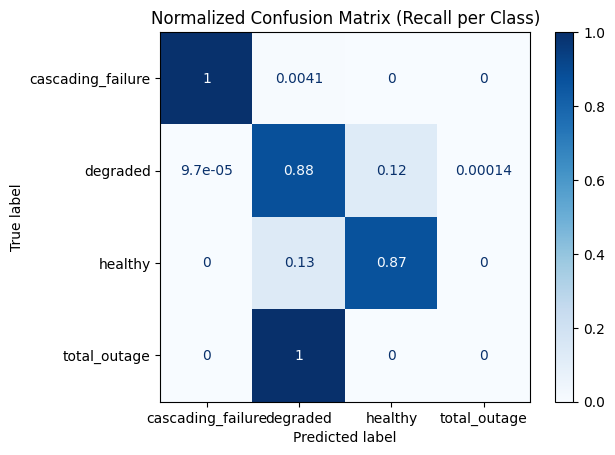

In [25]:
cm_normalized = confusion_matrix(y_test_system, y_pred_late_stage, normalize='true')

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, 
                              display_labels=best_model_late_stage.classes_)

disp.plot(cmap='Blues') 
plt.title("Normalized Confusion Matrix (Recall per Class)")
plt.show()

It appears that degraded and healthy were misclassified much more, and total outage was completely misclassified. Total outage is not as much as a concern because it's a small sample.

The most interesting part is looking at the feature importance. With the previous important features gone, I want to know which features the model is now using to classify these systems.

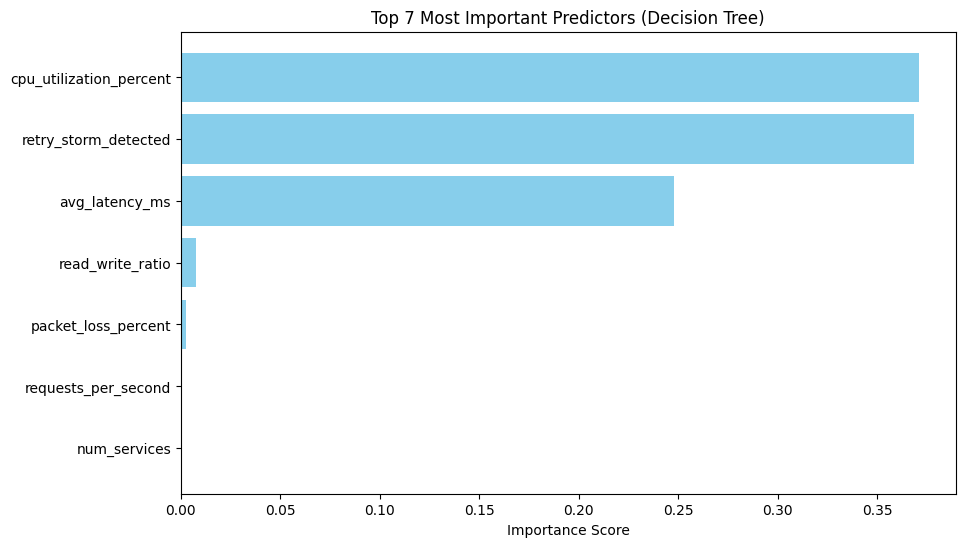

In [27]:
# look at best model
best_model = trained_models_late_stage['Decision Tree'] 

# get the predictor variable names and their importance value
cat_encoder = best_model.named_steps['prep'].named_transformers_['cat']
cat_features = cat_encoder.get_feature_names_out(categorical_cols)
all_features = np.concatenate([numerical_cols_late_stage, cat_features])
importances = best_model.named_steps['model'].feature_importances_

# create and sort df
feat_imp_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'].head(7), feat_imp_df['Importance'].head(7), color='skyblue')
plt.xlabel('Importance Score')
plt.title('Top 7 Most Important Predictors (Decision Tree)')
plt.gca().invert_yaxis()
plt.show()

We see that with the major predictors removed, the new important features are cpu_utilization_percent, retry_storm_detected, and avg_latency_ms.

With this, we can conclude this project. A major problem of this dataset was that it only provided snapshots of system metrics without time stamps. As such, I'm not able to truly predict which systems would become degraded soon since that's not a variable provided. This could also be the reason why all the models performed so well; because the system failure has already occurred, it's easier for the model to recognize the symptoms. For next time, I want to find a time series dataset so that I could try to predict the system states in the future. I would also like to have real world data. I suspect that part of the models' accuracy could be attributed to the artificial nature. I'm sure that real world data is much more messy, and that could pose an obstacle to the models.